# Bank Transactions Exploratory Data Analysis
## An exploratory analysis of 50 000 bank transactions examining transaction types, channels, customer behaviour, and location patterns.

## Setup And Data Loading (importing libraries and loading the dataset)

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
trans_ac = pd.read_csv('bank_transactions_dataset.csv')

In [145]:
trans_ac.head(11)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40
5,TX000006,AC00393,92.15,4/3/2023 17:15,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18,Student,172,1,781.68
6,TX000007,AC00199,7.08,2/15/2023 16:36,Credit,Seattle,D000241,140.212.253.222,M019,ATM,37,Doctor,139,1,13316.71
7,TX000008,AC00069,171.42,5/8/2023 17:47,Credit,Indianapolis,D000500,92.214.76.157,M020,Branch,67,Retired,291,1,2796.24
8,TX000009,AC00135,106.23,3/21/2023 16:59,Credit,Detroit,D000690,24.148.92.177,M035,Branch,51,Engineer,86,1,9095.14
9,TX000010,AC00385,815.96,3/31/2023 16:06,Debit,Nashville,D000199,32.169.88.41,M007,ATM,55,Doctor,120,1,1021.88


# Exploratory Data Analysis (EDA)
## What Are We Working With?

In [146]:
trans_ac.isnull().sum()

TransactionID          0
AccountID              0
TransactionAmount      0
TransactionDate        0
TransactionType        0
Location               0
DeviceID               0
IP Address             0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64

In [147]:
trans_ac.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  str    
 1   AccountID            50000 non-null  str    
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  str    
 4   TransactionType      50000 non-null  str    
 5   Location             50000 non-null  str    
 6   DeviceID             50000 non-null  str    
 7   IP Address           50000 non-null  str    
 8   MerchantID           50000 non-null  str    
 9   Channel              50000 non-null  str    
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  str    
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), str(10)
memory usage: 

In [148]:
trans_ac.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000


## Note from looking at the data:
### 1. No null values across the data
### 2. There are 4 columns that provide unique values:
###     - TransactionID
###     - AccountID
###     - DeviceID
###     - MerchantID  
### 3. TransactionDate should not appear as a string data type
### 4. Very big gap between min and max values for AccountBalance column (101.25 - 14977.99)

# Distribution Analysis of TransactionType

In [149]:
trans_type = trans_ac["TransactionType"].value_counts()
trans_type

TransactionType
Debit     38747
Credit    11253
Name: count, dtype: int64

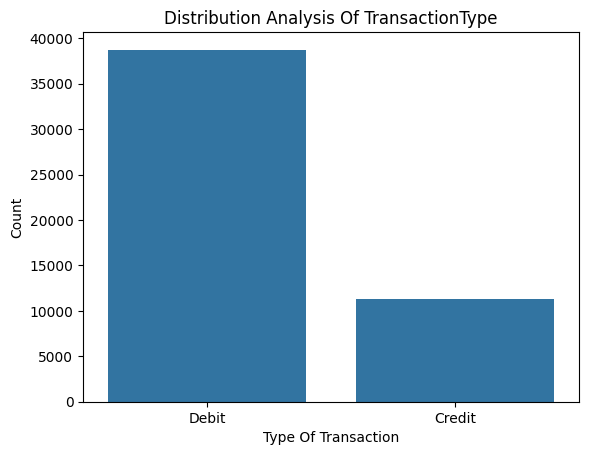

In [192]:
sns.barplot(data = trans_type)
plt.title("Distribution Analysis Of TransactionType")
plt.xlabel("Type Of Transaction")
plt.ylabel("Count")
plt.savefig("TransactionType.png")
plt.show()

### TransactionType: Why is there such a big gap between the number of debit and credit transactions?
#### Let's take a look at the channels used to complete the transactions

In [151]:
channel = trans_ac['Channel'].value_counts()
channel

Channel
Branch    17278
ATM       16552
Online    16170
Name: count, dtype: int64

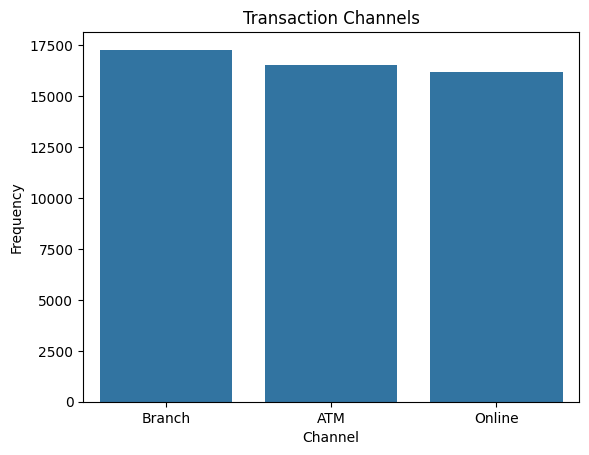

In [152]:
sns.barplot(data = channel)
plt.title('Transaction Channels')
plt.xlabel('Channel')
plt.ylabel('Frequency')
plt.savefig('Transaction_Channels.png')
plt.show()

### How are Debits and Credits spread out across the channels?

In [153]:
channels_1 = trans_ac.groupby('TransactionType')['Channel'].value_counts()
channels_1

TransactionType  Channel
Credit           Branch      5034
                 Online      4844
                 ATM         1375
Debit            ATM        15177
                 Branch     12244
                 Online     11326
Name: count, dtype: int64

In [154]:
df_channels1 = channels_1.reset_index()
df_channels1

,TransactionType,Channel,count
0,Credit,Branch,5034
1,Credit,Online,4844
2,Credit,ATM,1375
3,Debit,ATM,15177
4,Debit,Branch,12244
5,Debit,Online,11326


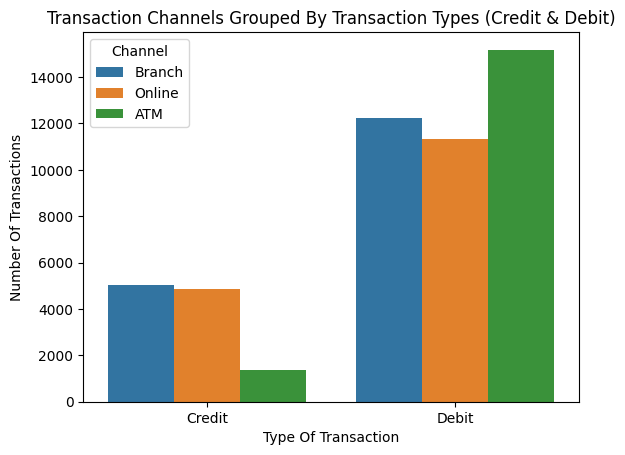

In [155]:
sns.barplot(data = df_channels1,
           x = 'TransactionType',
           y = 'count',
           hue = 'Channel')
plt.title('Transaction Channels Grouped By Transaction Types (Credit & Debit)')
plt.xlabel('Type Of Transaction')
plt.ylabel('Number Of Transactions')
plt.savefig('Channels Grouped Types.png')
plt.show()

## TransactionType Distribution 
## Analysing the split between debit and credit transactions across the dataset :
### 1. Debit transactions are mostly made through ATMs because they are used mostly for cash withdrawals.
### 2. Credit transactions are mostly made through branches, most likely because of loan distributions into the accounts of clients; other reasons could also include salary deposits and large deposits made at branches for security reasons.

# Transaction Channel Analysis

In [156]:
amounts1 = trans_ac.groupby(['Channel', 'TransactionType'])['TransactionAmount'].sum()
amounts1

Channel  TransactionType
ATM      Credit              415114.98
         Debit              4601112.35
Branch   Credit             1589893.94
         Debit              3454918.44
Online   Credit             1427242.70
         Debit              3405328.28
Name: TransactionAmount, dtype: float64

In [157]:
amounts_bar = amounts1.reset_index()
amounts_bar

,Channel,TransactionType,TransactionAmount
0,ATM,Credit,415114.98
1,ATM,Debit,4601112.35
2,Branch,Credit,1589893.94
3,Branch,Debit,3454918.44
4,Online,Credit,1427242.70
5,Online,Debit,3405328.28


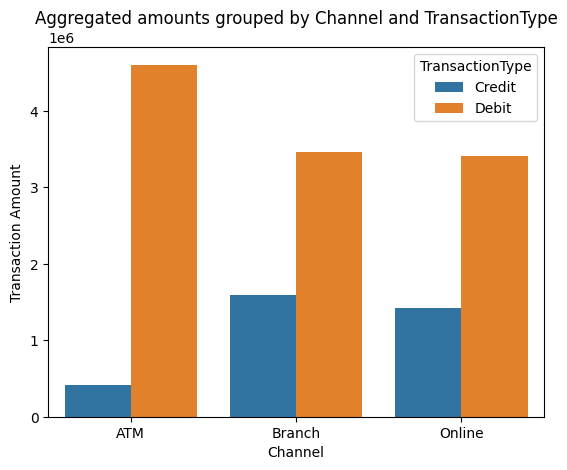

In [158]:
sns.barplot(data = amounts_bar,
           x = 'Channel',
           y = 'TransactionAmount',
           hue = 'TransactionType')
plt.title("Aggregated amounts grouped by Channel and TransactionType")
plt.xlabel("Channel")
plt.ylabel("Transaction Amount")
plt.show()

## Channel Distribution
## Analysing transaction volume and total amount across Branch, ATM, and Online channels.
### Insight: ATMs dominate total debit transactions in both count and sum, consistent with their primary use for cash withdrawals. This supports the earlier finding that debits drive overall transaction volume.

# Extraction, Analysis, and Visualisation Of TransactionDate

In [159]:
trans_ac['TransactionDate'] = pd.to_datetime(trans_ac['TransactionDate'], format='mixed', dayfirst=False)

## Datetime Parsing
#### TransactionDate was converted from string format and parsed to extract Month, DayOfWeek, and Hour columns for time-based analysis.

In [160]:
trans_ac['Month'] = trans_ac['TransactionDate'].dt.month
trans_ac['DayOfWeek'] = trans_ac['TransactionDate'].dt.day_name()
trans_ac['Hour'] = trans_ac['TransactionDate'].dt.hour

In [161]:
trans_ac[['TransactionDate', 'Month', 'DayOfWeek', 'Hour']].head(10)

,TransactionDate,Month,DayOfWeek,Hour
0,2023-04-11 16:29:00,4,Tuesday,16
1,2023-06-27 16:44:00,6,Tuesday,16
2,2023-07-10 18:16:00,7,Monday,18
3,2023-05-05 16:32:00,5,Friday,16
4,2023-10-16 17:51:00,10,Monday,17
5,2023-04-03 17:15:00,4,Monday,17
6,2023-02-15 16:36:00,2,Wednesday,16
7,2023-05-08 17:47:00,5,Monday,17
8,2023-03-21 16:59:00,3,Tuesday,16
9,2023-03-31 16:06:00,3,Friday,16


# Month Analysis

In [162]:
Month_1 = trans_ac.groupby('Month')['TransactionAmount'].sum()

In [163]:
Month_index = Month_1.reset_index()
Month_index

,Month,TransactionAmount
0,1,1277125.46
1,2,1170807.23
2,3,1270873.21
3,4,1165548.42
4,5,1270332.00
5,6,1199823.39
6,7,1260540.64
7,8,1295119.25
8,9,1244302.09
9,10,1278181.09


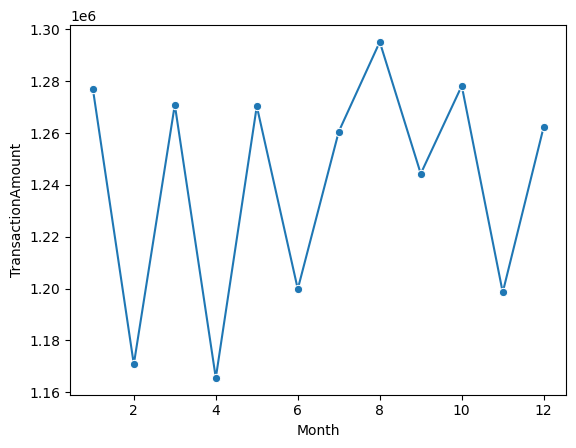

In [164]:
sns.lineplot(data = Month_index,
            x = 'Month',
            y = 'TransactionAmount',
            marker = 'o')
plt.savefig('MonthAnalysis.png')

In [165]:
Month_2 = trans_ac.groupby(['Month', 'TransactionType'])['TransactionAmount'].sum()
Month_2

Month  TransactionType
1      Credit             287655.45
       Debit              989470.01
2      Credit             251966.30
       Debit              918840.93
3      Credit             294995.63
       Debit              975877.58
4      Credit             263031.49
       Debit              902516.93
5      Credit             286536.28
       Debit              983795.72
6      Credit             257103.02
       Debit              942720.37
7      Credit             283199.07
       Debit              977341.57
8      Credit             316789.23
       Debit              978330.02
9      Credit             300409.58
       Debit              943892.51
10     Credit             294926.99
       Debit              983254.10
11     Credit             277256.86
       Debit              921293.43
12     Credit             318381.72
       Debit              944025.90
Name: TransactionAmount, dtype: float64

In [166]:
Month_Type = Month_2.reset_index()
Month_Type

,Month,TransactionType,TransactionAmount
0,1,Credit,287655.45
1,1,Debit,989470.01
2,2,Credit,251966.30
3,2,Debit,918840.93
4,3,Credit,294995.63
5,3,Debit,975877.58
6,4,Credit,263031.49
7,4,Debit,902516.93
8,5,Credit,286536.28
9,5,Debit,983795.72


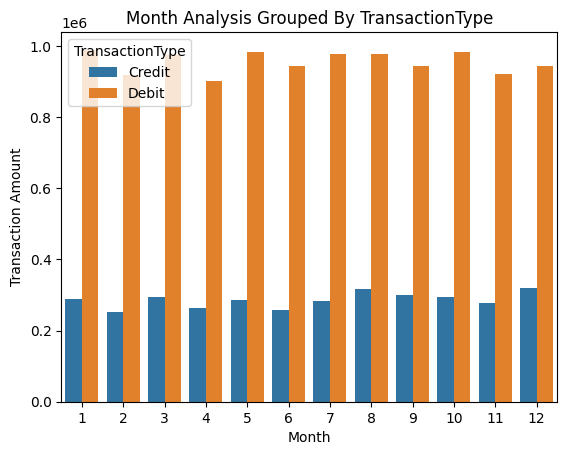

In [167]:
sns.barplot(data = Month_Type,
           x = 'Month',
           y = 'TransactionAmount',
           hue = 'TransactionType')
plt.title('Month Analysis Grouped By TransactionType')
plt.xlabel('Month')
plt.ylabel('Transaction Amount')
plt.savefig('Month-Type Grouping.png')
plt.show()

## Examining how transaction amounts vary across the 12 months, grouped by TransactionType.
### Insight: Credit distribution remains relatively even throughout the year. Debit activity drives the monthly fluctuations, with notable dips in February, April, June, and November. These dips likely reflect post-January spending caution, Easter period cash flow improvements, mid-year saving behaviour, and pre-December holiday saving, respectively.

# DayOfWeek Analysis

In [168]:
dayofweek = trans_ac.groupby(['DayOfWeek', 'TransactionType'])['TransactionAmount'].sum()
dayofweek

DayOfWeek  TransactionType
Friday     Credit              489513.27
           Debit              1653922.50
Monday     Credit              542600.35
           Debit              1826428.52
Saturday   Credit              452464.24
           Debit              1542934.87
Sunday     Credit              467825.47
           Debit              1513124.58
Thursday   Credit              475328.70
           Debit              1656249.82
Tuesday    Credit              496036.71
           Debit              1631202.26
Wednesday  Credit              508482.88
           Debit              1637496.52
Name: TransactionAmount, dtype: float64

In [169]:
dayofweek_1 = dayofweek.reset_index()
dayofweek_1

,DayOfWeek,TransactionType,TransactionAmount
0,Friday,Credit,489513.27
1,Friday,Debit,1653922.50
2,Monday,Credit,542600.35
3,Monday,Debit,1826428.52
4,Saturday,Credit,452464.24
5,Saturday,Debit,1542934.87
6,Sunday,Credit,467825.47
7,Sunday,Debit,1513124.58
8,Thursday,Credit,475328.70
9,Thursday,Debit,1656249.82


In [170]:
sorted_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

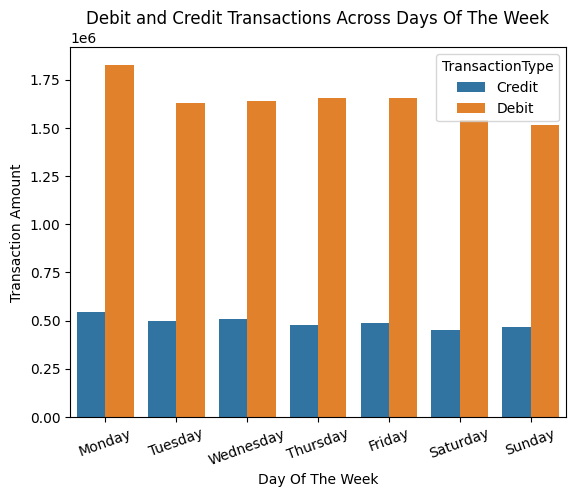

In [171]:
sns.barplot(data = dayofweek_1,
           x = 'DayOfWeek',
           y = 'TransactionAmount',
           hue = 'TransactionType',
           order = sorted_days)
plt.title('Debit and Credit Transactions Across Days Of The Week')
plt.xlabel('Day Of The Week')
plt.xticks(rotation = 20)
plt.ylabel('Transaction Amount')
plt.savefig("DayOfWeek Analysis")
plt.show()

## Examining how transaction amounts vary across the days of the week, grouped by TransactionType.
### Insight: Monday records the highest debit activity, driven by start-of-week spending patterns, restocking groceries, resuming commutes, cash withdrawals for the week ahead, and the return of normal business hours after the weekend. Credit distribution remains relatively flat across all days. Saturday and Sunday show the lowest overall activity, reflecting reduced business operations and spending over the weekend.

## Hour Analysis
### Hour analysis was attempted, but the dataset only contains 4 unique hour values (0, 16, 17, 18), suggesting the data was synthetically generated. Meaningful time-of-day insights cannot be drawn from this data. This section has been skipped accordingly.

# Customer Occupation Analysis

### Number Of Transactions Across Occupations

In [172]:
customer = trans_ac.groupby('CustomerOccupation')['CustomerOccupation'].value_counts()
customer

CustomerOccupation
Doctor      12578
Engineer    12491
Retired     11872
Student     13059
Name: count, dtype: int64

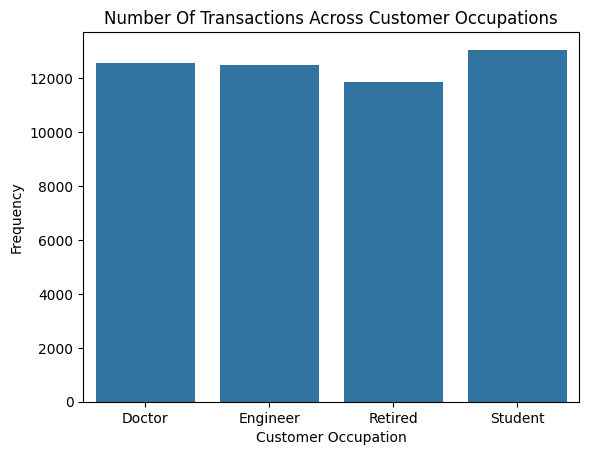

In [173]:
sns.barplot(data = customer)
plt.title("Number Of Transactions Across Customer Occupations")
plt.xlabel("Customer Occupation")
plt.ylabel("Frequency")
plt.savefig("counts_Occupation.png")
plt.show()

### Averages Across Occupations

In [174]:
customer_1 = trans_ac.groupby('CustomerOccupation')['TransactionAmount'].mean()
customer_1

CustomerOccupation
Doctor      291.214523
Engineer    288.537243
Retired     297.937759
Student     313.154043
Name: TransactionAmount, dtype: float64

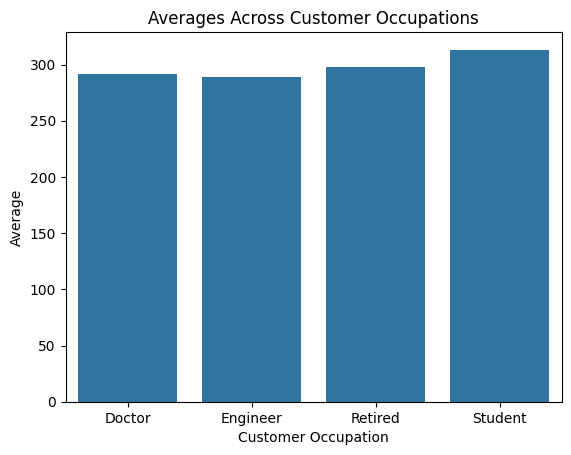

In [175]:
sns.barplot(data = customer_1)
plt.title("Averages Across Customer Occupations")
plt.xlabel("Customer Occupation")
plt.ylabel("Average")
plt.savefig("averages_Occupation.png")
plt.show()

### Totals Accross Occupations

In [176]:
customer_2 = trans_ac.groupby('CustomerOccupation')['TransactionAmount'].sum()
customer_2

CustomerOccupation
Doctor      3662896.27
Engineer    3604118.70
Retired     3537117.07
Student     4089478.65
Name: TransactionAmount, dtype: float64

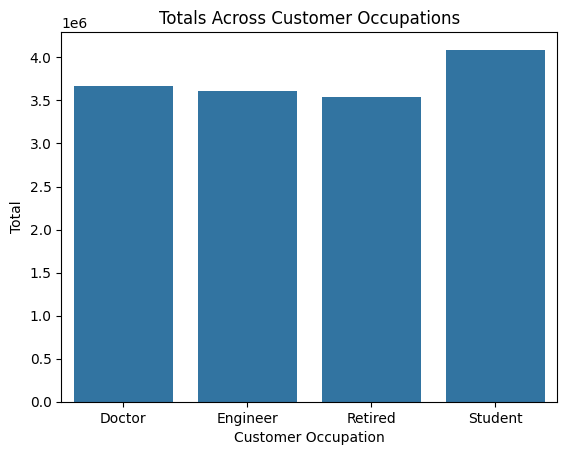

In [177]:
sns.barplot(data = customer_2)
plt.title("Totals Across Customer Occupations")
plt.xlabel("Customer Occupation")
plt.ylabel("Total")
plt.savefig("totals_Occupations.png")
plt.show()

## Analysing transaction frequency, average transaction amount, and total transaction amount across customer occupations.
### Insight: Students lead across all three metrics: count, average, and total transaction amount. While the margins in count and average are small, the combination of frequent transactions and a slightly higher average spend results in students moving the most money overall. This reflects the dual spending pattern of students – frequent small day-to-day purchases alongside larger one-time acquisitions such as laptops, textbooks, and accommodation.

# Location Analysis

In [178]:
location = trans_ac.groupby('Location')['Location'].value_counts()
location

Location
Albuquerque          849
Atlanta             1245
Austin              1146
Baltimore            996
Boston              1203
Charlotte           1347
Chicago             1195
Colorado Springs    1141
Columbus            1048
Dallas               971
Denver              1267
Detroit             1230
El Paso              997
Fort Worth          1396
Fresno              1177
Houston             1217
Indianapolis        1104
Jacksonville        1216
Kansas City         1211
Las Vegas           1124
Los Angeles         1318
Louisville          1031
Memphis             1330
Mesa                1228
Miami               1278
Milwaukee           1100
Nashville           1124
New York            1150
Oklahoma City       1345
Omaha               1298
Philadelphia        1343
Phoenix             1155
Portland             811
Raleigh             1187
Sacramento          1055
San Antonio         1195
San Diego           1139
San Francisco       1105
San Jose            1159
Seattle         

In [179]:
location_1 = location.sort_values(ascending = False).head(10)
location_1

Location
Fort Worth       1396
Charlotte        1347
Oklahoma City    1345
Philadelphia     1343
Memphis          1330
Tucson           1322
Los Angeles      1318
Omaha            1298
Miami            1278
Denver           1267
Name: count, dtype: int64

In [180]:
location_2 = location_1.reset_index()
location_2

,Location,count
0,Fort Worth,1396
1,Charlotte,1347
2,Oklahoma City,1345
3,Philadelphia,1343
4,Memphis,1330
5,Tucson,1322
6,Los Angeles,1318
7,Omaha,1298
8,Miami,1278
9,Denver,1267


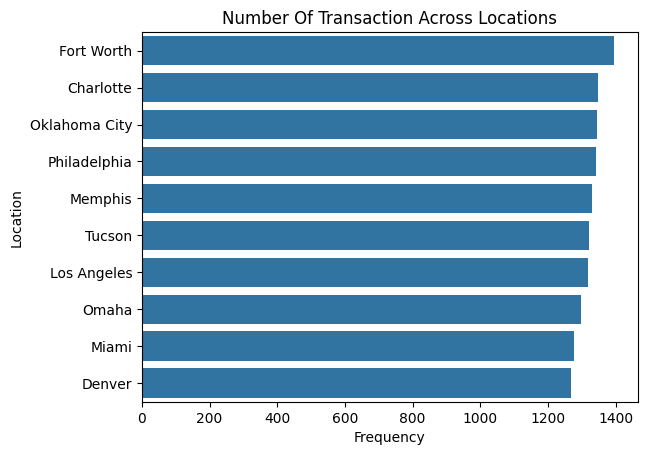

In [181]:
sns.barplot( data = location_2,
             x = "count",
             y = "Location")
plt.title("Number Of Transaction Across Locations")
plt.xlabel("Frequency")
plt.ylabel("Location")
plt.savefig("counts_Location.png")
plt.show()

In [182]:
location_3 = trans_ac.groupby('Location')['TransactionAmount'].sum()
location_3.sort_values(ascending = False).head(10)

Location
Austin           453508.80
Memphis          445646.01
Oklahoma City    444559.54
San Antonio      423005.49
Fort Worth       422279.87
Jacksonville     411470.80
Phoenix          410725.84
Tucson           401159.06
Detroit          396371.02
Philadelphia     395031.93
Name: TransactionAmount, dtype: float64

In [183]:
location_4 = trans_ac.groupby(['Location', 'TransactionType'])['TransactionAmount'].sum()
location_5 = location_4.sort_values().head(10)
location_6 = location_5.sort_values(ascending = False).head(10)
location_6

Location       TransactionType
Albuquerque    Credit             53869.34
New York       Credit             53622.58
Portland       Credit             52915.38
Charlotte      Credit             50894.76
San Francisco  Credit             49815.54
Seattle        Credit             49807.79
Dallas         Credit             46954.83
Milwaukee      Credit             45933.43
Denver         Credit             44238.35
El Paso        Credit             27623.30
Name: TransactionAmount, dtype: float64

In [184]:
location_4 = trans_ac.groupby(['Location', 'TransactionType'])['TransactionAmount'].sum()
location_7 = location_4.sort_values(ascending = False).head(10)
location_7

Location          TransactionType
El Paso           Debit              361346.81
San Antonio       Debit              354478.36
Memphis           Debit              345041.09
Oklahoma City     Debit              343487.50
Tucson            Debit              324293.57
Philadelphia      Debit              319244.01
Fort Worth        Debit              319205.69
Detroit           Debit              313326.52
Columbus          Debit              312972.78
Colorado Springs  Debit              306234.34
Name: TransactionAmount, dtype: float64

In [185]:
location_8 = trans_ac.groupby('Location')['TransactionAmount'].mean()
location_8.sort_values(ascending = False).head(10)

Location
Austin              395.731937
El Paso             390.140532
Columbus            355.905735
Phoenix             355.606788
San Antonio         353.979490
Washington          349.060207
Colorado Springs    340.454733
Jacksonville        338.380592
Memphis             335.072188
Oklahoma City       330.527539
Name: TransactionAmount, dtype: float64

### Location and Transaction Type Visualisation

#### Reset Indexes

In [186]:
location_9 = location_6.reset_index()
location_9

,Location,TransactionType,TransactionAmount
0,Albuquerque,Credit,53869.34
1,New York,Credit,53622.58
2,Portland,Credit,52915.38
3,Charlotte,Credit,50894.76
4,San Francisco,Credit,49815.54
5,Seattle,Credit,49807.79
6,Dallas,Credit,46954.83
7,Milwaukee,Credit,45933.43
8,Denver,Credit,44238.35
9,El Paso,Credit,27623.30


In [187]:
location_10 = location_7.reset_index()
location_10

,Location,TransactionType,TransactionAmount
0,El Paso,Debit,361346.81
1,San Antonio,Debit,354478.36
2,Memphis,Debit,345041.09
3,Oklahoma City,Debit,343487.50
4,Tucson,Debit,324293.57
5,Philadelphia,Debit,319244.01
6,Fort Worth,Debit,319205.69
7,Detroit,Debit,313326.52
8,Columbus,Debit,312972.78
9,Colorado Springs,Debit,306234.34


#### Visualise Credits

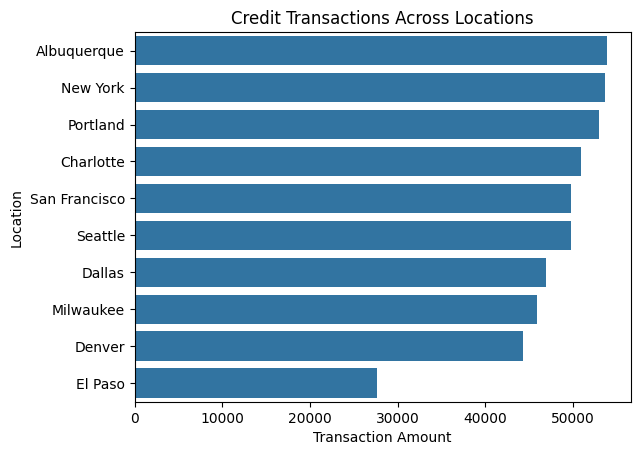

In [188]:
sns.barplot(data = location_9,
           x = "TransactionAmount",
           y = "Location")
plt.title("Credit Transactions Across Locations")
plt.xlabel("Transaction Amount")
plt.ylabel("Location")
plt.savefig("credits_Locations.png")
plt.show()

#### Visualise Debits

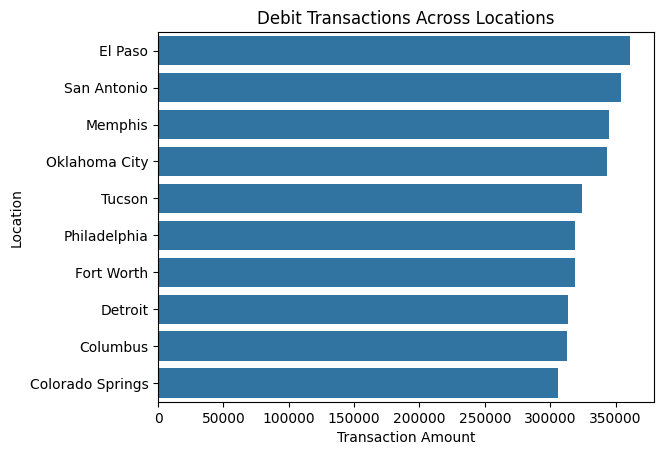

In [189]:
sns.barplot(data = location_10,
           x = "TransactionAmount",
           y = "Location")
plt.title("Debit Transactions Across Locations")
plt.xlabel("Transaction Amount")
plt.ylabel("Location")
plt.savefig("debits_Locations.png")
plt.show()

## Analysing the top 10 locations by transaction count, total amount, and transaction amount grouped by transaction type.
### Insight: A city's ranking is determined by a combination of transaction frequency and average transaction amount rather than either metric alone. Cities with a higher cost of living tend to record fewer but higher-value transactions, while lower-cost-of-living cities transact more frequently at lower averages. This pattern is evident in the credit analysis; Albuquerque and Portland, despite ranking lowest in overall transaction count, lead in total credit amount, suggesting their credit transactions are of significantly higher value. Austin leads in total transaction amount overall, driven not by count but by the highest average transaction amount across all cities.

# Conclusion

## This analysis explored 50,000 bank transactions across transaction types, channels, amounts, customer occupations, and locations.          The most significant findings were ATMs dominating debit transactions due to their primary use for cash withdrawals and students leading all occupations in total money movement, driven by a combination of frequent low-value purchases and periodic high-value acquisitions. Data quality limitations in the TransactionDate column restricted time-of-day analysis, as only 4 unique hour values were present in the dataset. Overall, customer banking behaviour is shaped by channel preference, seasonal and weekly spending patterns, occupation, and location.